## Visualización de `datos_crypto_limpios.parquet`

Este notebook carga el dataset de precios cripto (índice temporal + columnas `*USDT`) y genera:
- Vista rápida del dataset
- Estadísticos y rango temporal
- Gráficas de precios (crudos y normalizados)
- Retornos (simples y log)
- Correlaciones
- Volatilidad rolling y drawdowns

**Archivo fuente**: `datos_crypto_limpios.parquet`


In [1]:
# Si te falta alguna librería, descomenta y ejecuta:
# %pip install -U pandas pyarrow matplotlib seaborn


In [2]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

PARQUET_NAME = "datos_crypto_limpios.parquet"

# Soporta ejecutar el notebook tanto desde la raíz del repo como desde `data/`
candidates = [
    Path("data") / PARQUET_NAME,  # cwd = raíz
    Path(PARQUET_NAME),           # cwd = data/
]
DATA_PATH = next((p for p in candidates if p.exists()), None)
assert DATA_PATH is not None, f"No existe el archivo parquet en: {[str(p) for p in candidates]}"

df = pd.read_parquet(DATA_PATH)

# Asegurar que el índice sea datetime (en este parquet ya viene como índice)
if not isinstance(df.index, pd.DatetimeIndex):
    # Si viniera como columna, intenta usarla
    for candidate in ["date", "datetime", "timestamp", "time", "__index_level_0__"]:
        if candidate in df.columns:
            df[candidate] = pd.to_datetime(df[candidate], errors="coerce")
            df = df.set_index(candidate)
            break
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, errors="coerce")

# Ordenar por tiempo
df = df.sort_index()

# Mantener solo columnas numéricas (precios)
price_cols = df.select_dtypes(include=["number"]).columns.tolist()
prices = df[price_cols].copy()

prices.head()

,ADAUSDT,BNBUSDT,BTCUSDT,DOGEUSDT,DOTUSDT,ETHUSDT,LINKUSDT,LTCUSDT,SOLUSDT,XRPUSDT
2020-08-18 23:00:00,0.13703,23.0786,12026.09,0.003518,2.9999,423.96,16.2455,66.21,3.3926,0.30279
2020-08-18 23:05:00,0.13724,23.0964,12034.70,0.003520,2.9261,424.56,16.2455,66.31,3.3850,0.30349
2020-08-18 23:10:00,0.13693,23.0214,12014.55,0.003505,2.9999,423.32,16.1453,66.00,3.4066,0.30252
2020-08-18 23:15:00,0.13707,23.0280,12018.19,0.003512,2.9729,423.51,16.2096,66.12,3.4023,0.30277
2020-08-18 23:20:00,0.13702,23.0327,12001.51,0.003503,3.0100,423.03,16.1805,66.01,3.4000,0.30267


In [3]:
# Vista general
print("Filas, columnas:", prices.shape)
print("Columnas:", list(prices.columns))
print("Rango temporal:", prices.index.min(), "->", prices.index.max())

# Frecuencia aproximada (mediana de diferencias)
deltas = prices.index.to_series().diff().dropna()
print("Frecuencia mediana:", deltas.median())

display(prices.tail())
display(prices.describe().T)

Filas, columnas: (581489, 10)
Columnas: ['ADAUSDT', 'BNBUSDT', 'BTCUSDT', 'DOGEUSDT', 'DOTUSDT', 'ETHUSDT', 'LINKUSDT', 'LTCUSDT', 'SOLUSDT', 'XRPUSDT']
Rango temporal: 2020-08-18 23:00:00 -> 2026-02-28 23:55:00
Frecuencia mediana: 0 days 00:05:00


,ADAUSDT,BNBUSDT,BTCUSDT,DOGEUSDT,DOTUSDT,ETHUSDT,LINKUSDT,LTCUSDT,SOLUSDT,XRPUSDT
2026-02-28 23:35:00,0.2808,615.62,66779.02,0.09388,1.655,1958.43,8.81,54.26,83.98,1.3743
2026-02-28 23:40:00,0.2811,616.33,66886.16,0.09396,1.655,1961.20,8.84,54.36,84.10,1.3761
2026-02-28 23:45:00,0.2819,617.70,67032.56,0.09416,1.666,1966.30,8.86,54.46,84.45,1.3794
2026-02-28 23:50:00,0.2816,617.01,66980.49,0.09403,1.671,1965.07,8.85,54.36,84.32,1.3779
2026-02-28 23:55:00,0.2810,617.14,66973.26,0.09405,1.662,1964.51,8.85,54.40,84.35,1.3762


,count,mean,std,min,25%,50%,75%,max
ADAUSDT,581489.0,0.691491,0.520269,0.075640,0.35290,0.49872,0.88080,3.09500
BNBUSDT,581489.0,437.460084,243.855178,18.027500,270.40000,384.00000,600.00000,1369.64000
BTCUSDT,581489.0,52514.280788,30175.498520,9890.260000,27422.54000,44187.98000,68660.00000,126011.18000
DOGEUSDT,581489.0,0.139206,0.097373,0.002456,0.07152,0.11680,0.18861,0.73623
DOTUSDT,581489.0,10.593231,10.487389,1.112000,4.38900,6.17800,10.23300,55.03000
ETHUSDT,581489.0,2395.904504,1015.633564,312.330000,1667.01000,2335.56000,3155.01000,4951.50000
LINKUSDT,581489.0,15.180459,7.731940,4.955000,8.12800,13.86900,19.01000,52.75300
LTCUSDT,581489.0,101.182950,48.759232,40.400000,68.63000,86.84000,115.76000,411.02000
SOLUSDT,581489.0,92.525359,72.340899,1.081500,23.30000,87.69000,151.44000,294.69000
XRPUSDT,581489.0,0.997894,0.814094,0.173790,0.46950,0.60220,1.26510,3.65350


In [4]:
# (Opcional) Submuestreo para que las gráficas sean más rápidas
# Si tus datos están cada 5 minutos, puedes bajar a 1h o 1D.
RESAMPLE_RULE = "1H"  # prueba "15min", "1H", "4H", "1D"
prices_rs = prices.resample(RESAMPLE_RULE).last().dropna(how="any")

print("Resample:", RESAMPLE_RULE, "->", prices_rs.shape)
prices_rs.head()

Resample: 1H -> (48462, 10)


C:\Users\Usuario\AppData\Local\Temp\ipykernel_15812\3613863857.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  prices_rs = prices.resample(RESAMPLE_RULE).last().dropna(how="any")


,ADAUSDT,BNBUSDT,BTCUSDT,DOGEUSDT,DOTUSDT,ETHUSDT,LINKUSDT,LTCUSDT,SOLUSDT,XRPUSDT
2020-08-18 23:00:00,0.13691,22.9705,11945.01,0.003476,3.1000,421.95,16.1927,65.40,3.3407,0.30251
2020-08-19 00:00:00,0.13710,23.1631,11985.88,0.003522,3.1050,424.41,16.3987,66.14,3.3986,0.30263
2020-08-19 01:00:00,0.13683,23.0613,11968.39,0.003517,3.1063,423.08,16.3170,66.07,3.4691,0.30251
2020-08-19 02:00:00,0.13494,22.7562,11912.08,0.003500,2.9628,420.49,16.3663,64.61,3.3300,0.29914
2020-08-19 03:00:00,0.13172,22.5431,11837.11,0.003468,2.8850,415.66,15.4205,62.70,3.1075,0.29353


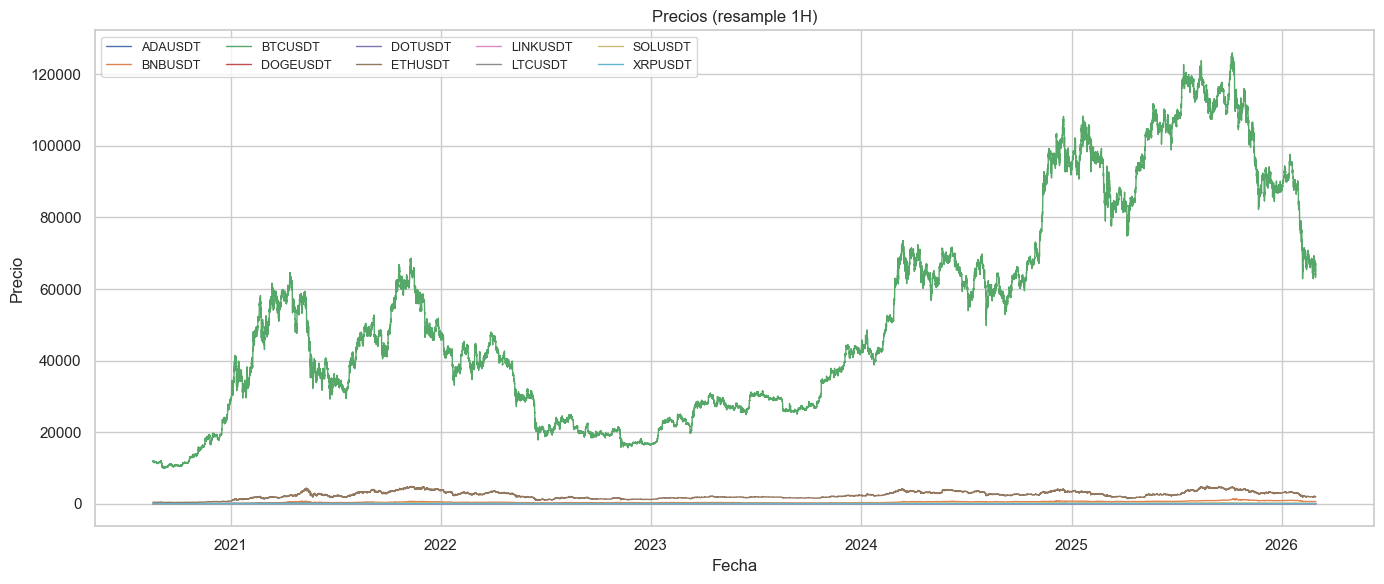

In [5]:
# Gráfica de precios (múltiples series)
plt.figure(figsize=(14, 6))
for c in prices_rs.columns:
    plt.plot(prices_rs.index, prices_rs[c], linewidth=1, label=c)
plt.title(f"Precios (resample {RESAMPLE_RULE})")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend(ncols=5, fontsize=9)
plt.tight_layout()
plt.show()

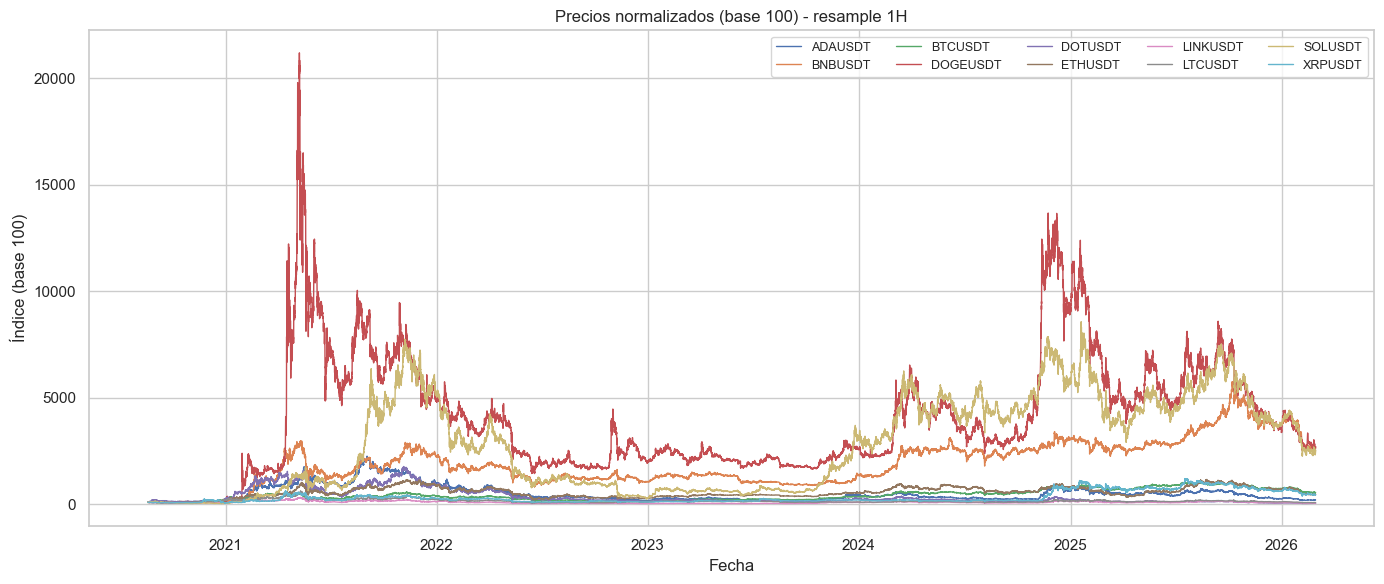

In [6]:
# Precios normalizados (base 100) para comparar rendimiento relativo
norm = (prices_rs / prices_rs.iloc[0]) * 100

plt.figure(figsize=(14, 6))
for c in norm.columns:
    plt.plot(norm.index, norm[c], linewidth=1, label=c)
plt.title(f"Precios normalizados (base 100) - resample {RESAMPLE_RULE}")
plt.xlabel("Fecha")
plt.ylabel("Índice (base 100)")
plt.legend(ncols=5, fontsize=9)
plt.tight_layout()
plt.show()

,count,mean,std,min,1%,5%,50%,95%,99%,max
ADAUSDT,48461.0,0.000076,0.011037,-0.215392,-0.030638,-0.015485,0.000000,0.015835,0.032250,0.337091
BNBUSDT,48461.0,0.000104,0.008537,-0.155260,-0.025010,-0.011619,0.000147,0.011472,0.024663,0.148012
BTCUSDT,48461.0,0.000056,0.006370,-0.089545,-0.019075,-0.009025,0.000056,0.009162,0.018705,0.123159
DOGEUSDT,48461.0,0.000166,0.014258,-0.253911,-0.035383,-0.016621,0.000000,0.016355,0.038834,0.700192
DOTUSDT,48461.0,0.000053,0.011432,-0.316137,-0.031631,-0.016228,0.000000,0.016300,0.032906,0.213270
ETHUSDT,48461.0,0.000067,0.008364,-0.130794,-0.024822,-0.012217,0.000074,0.012144,0.024473,0.095555
LINKUSDT,48461.0,0.000051,0.011241,-0.230488,-0.031999,-0.016412,0.000000,0.016667,0.031896,0.121678
LTCUSDT,48461.0,0.000046,0.009991,-0.259478,-0.028481,-0.014192,0.000000,0.014011,0.028503,0.249425
SOLUSDT,48461.0,0.000154,0.013220,-0.192840,-0.036006,-0.018532,0.000000,0.019142,0.038922,0.306499
XRPUSDT,48461.0,0.000094,0.011190,-0.201434,-0.031576,-0.014283,0.000122,0.014152,0.033094,0.277460


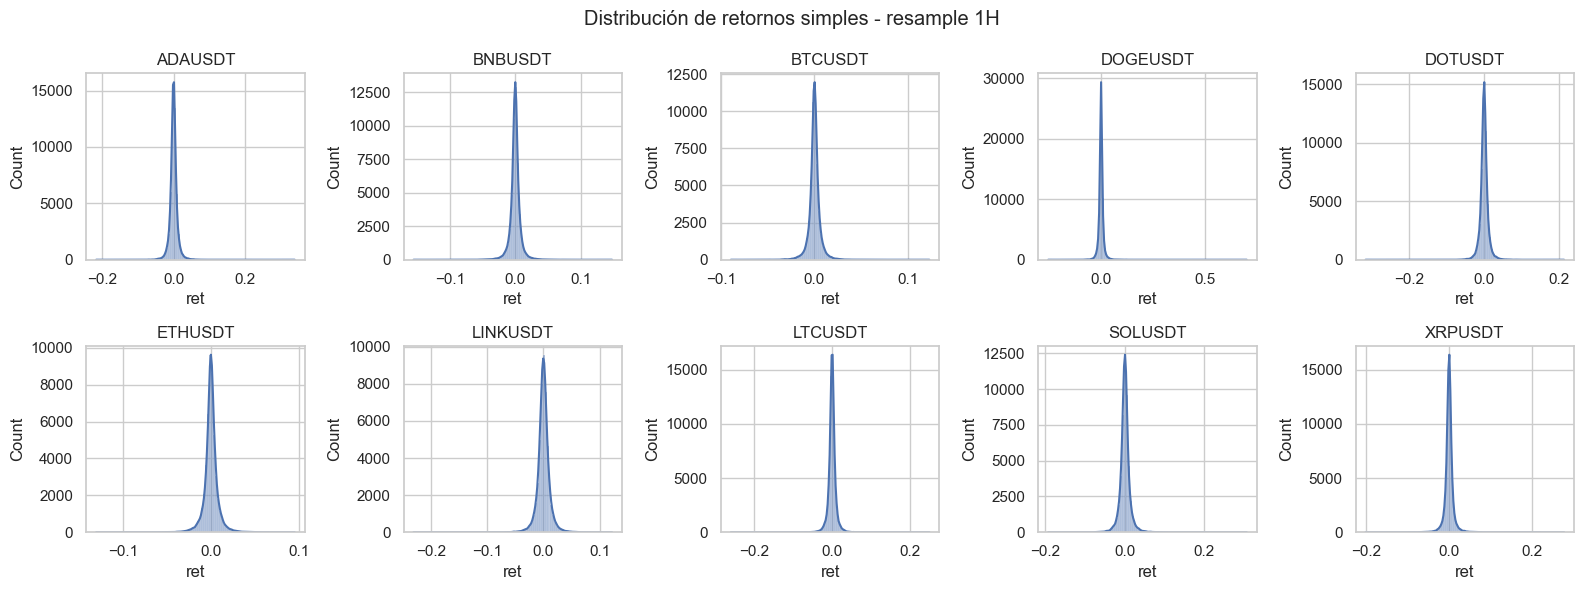

In [7]:
# Retornos (simples y log)
ret = prices_rs.pct_change().dropna(how="any")
logret = np.log(prices_rs).diff().dropna(how="any")

display(ret.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

# Distribución de retornos (histogramas)
fig, axes = plt.subplots(2, 5, figsize=(16, 6), sharex=False, sharey=False)
axes = axes.ravel()
for i, c in enumerate(ret.columns):
    ax = axes[i]
    sns.histplot(ret[c], bins=100, kde=True, ax=ax)
    ax.set_title(c)
    ax.set_xlabel("ret")
plt.suptitle(f"Distribución de retornos simples - resample {RESAMPLE_RULE}")
plt.tight_layout()
plt.show()

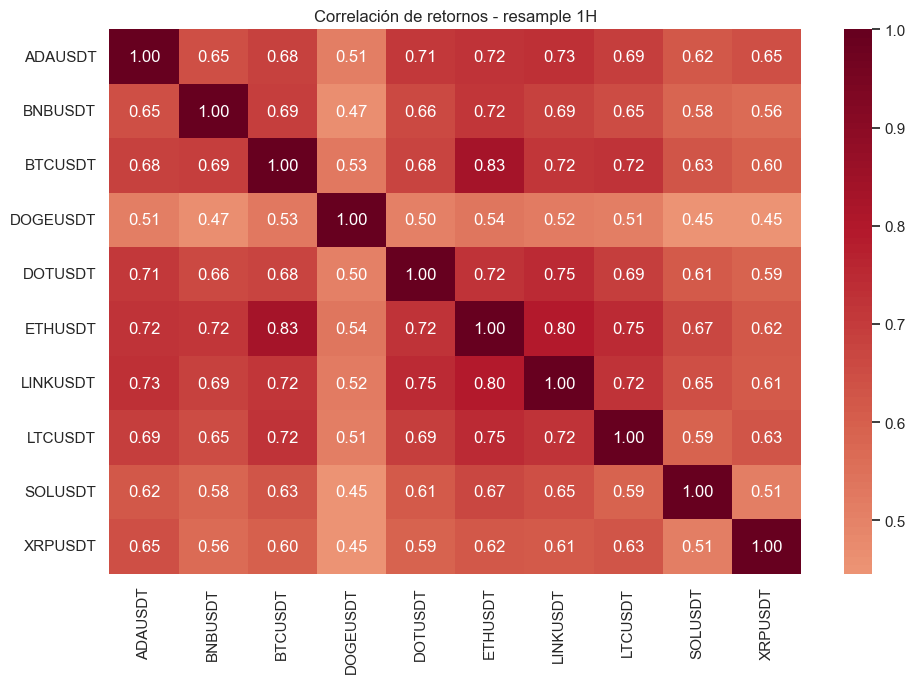

In [8]:
# Correlación (sobre retornos) + heatmap
corr = ret.corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title(f"Correlación de retornos - resample {RESAMPLE_RULE}")
plt.tight_layout()
plt.show()

# Pairplot (puede ser pesado; activa si quieres)
DO_PAIRPLOT = False
if DO_PAIRPLOT:
    sample = ret.sample(min(len(ret), 2000), random_state=42)
    sns.pairplot(sample)
    plt.show()

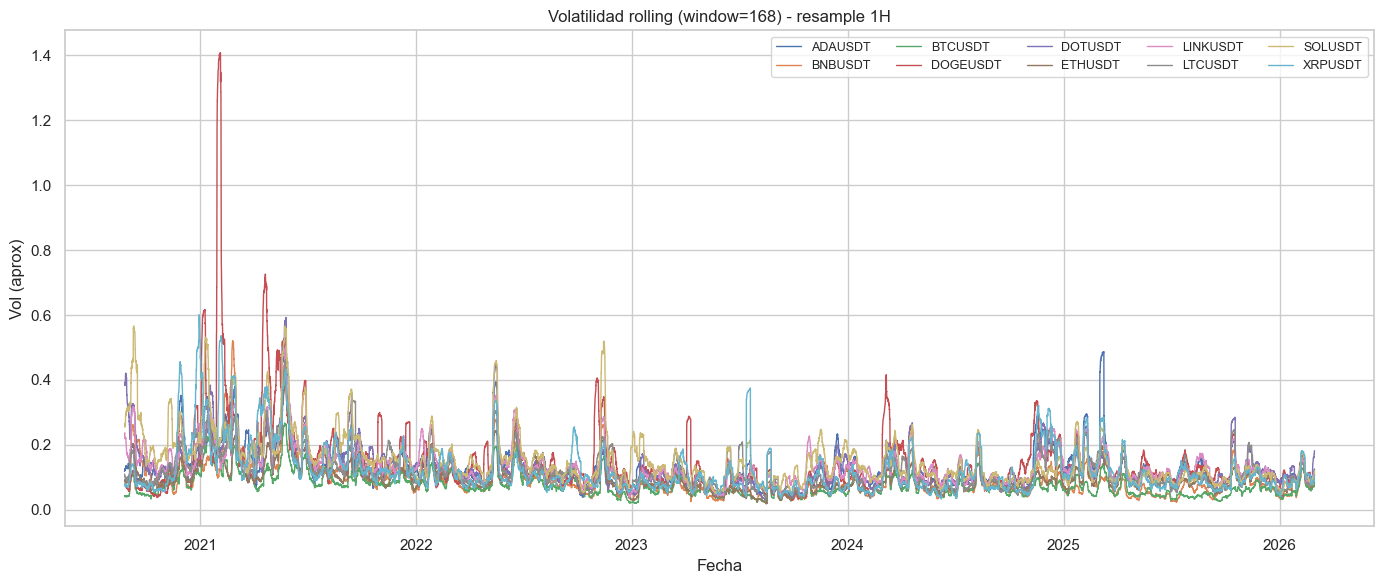

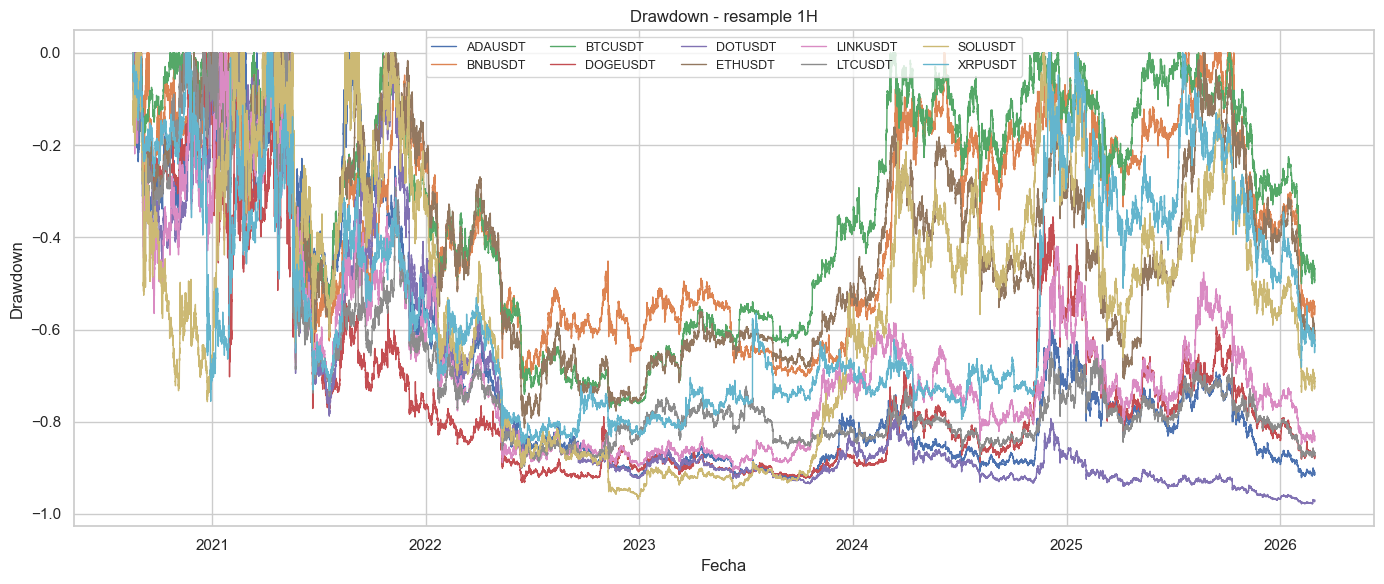

DOTUSDT    -0.977685
SOLUSDT    -0.967962
DOGEUSDT   -0.931788
ADAUSDT    -0.923069
LINKUSDT   -0.904800
LTCUSDT    -0.900937
XRPUSDT    -0.848279
ETHUSDT    -0.813430
BTCUSDT    -0.771985
BNBUSDT    -0.725381
dtype: float64

In [9]:
# Volatilidad rolling (en retornos) y drawdown
WINDOW = 24 * 7  # si resample=1H -> 1 semana; ajusta según RESAMPLE_RULE

rolling_vol = ret.rolling(WINDOW).std() * np.sqrt(WINDOW)  # volatilidad anualizada aprox. (escala relativa)

plt.figure(figsize=(14, 6))
for c in rolling_vol.columns:
    plt.plot(rolling_vol.index, rolling_vol[c], linewidth=1, label=c)
plt.title(f"Volatilidad rolling (window={WINDOW}) - resample {RESAMPLE_RULE}")
plt.xlabel("Fecha")
plt.ylabel("Vol (aprox)")
plt.legend(ncols=5, fontsize=9)
plt.tight_layout()
plt.show()

# Drawdown sobre precios
cummax = prices_rs.cummax()
drawdown = prices_rs / cummax - 1

plt.figure(figsize=(14, 6))
for c in drawdown.columns:
    plt.plot(drawdown.index, drawdown[c], linewidth=1, label=c)
plt.title(f"Drawdown - resample {RESAMPLE_RULE}")
plt.xlabel("Fecha")
plt.ylabel("Drawdown")
plt.legend(ncols=5, fontsize=9)
plt.tight_layout()
plt.show()

display(drawdown.min().sort_values())  # máximo drawdown por activo

In [10]:
# Dataset en formato largo (útil para algunas visualizaciones)
long_df = (
    prices_rs
    .reset_index(names=["datetime"])
    .melt(id_vars="datetime", var_name="symbol", value_name="price")
)

display(long_df.head())
print("long_df shape:", long_df.shape)

,datetime,symbol,price
0,2020-08-18 23:00:00,ADAUSDT,0.13691
1,2020-08-19 00:00:00,ADAUSDT,0.13710
2,2020-08-19 01:00:00,ADAUSDT,0.13683
3,2020-08-19 02:00:00,ADAUSDT,0.13494
4,2020-08-19 03:00:00,ADAUSDT,0.13172


long_df shape: (484620, 3)


C:\Users\Usuario\AppData\Local\Temp\ipykernel_15812\1210209374.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sub = prices.loc[START:END, [s for s in SYMS if s in prices.columns]].resample(RESAMPLE_RULE).last().dropna(how="any")


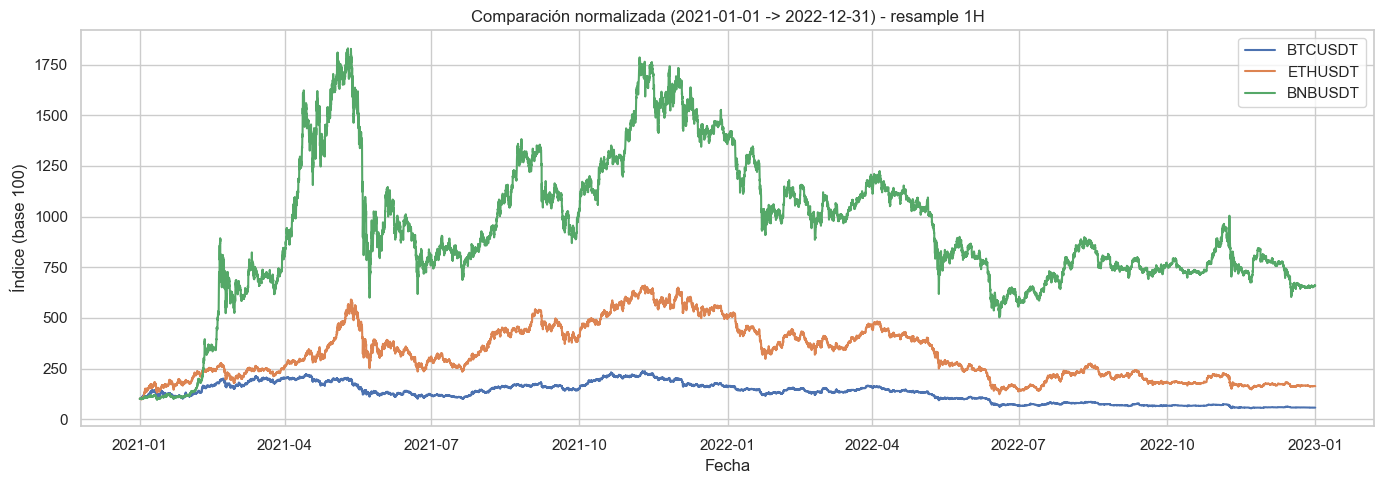

In [11]:
# Ejemplo: comparar 2-3 activos en un periodo concreto
SYMS = ["BTCUSDT", "ETHUSDT", "BNBUSDT"]
START = "2021-01-01"
END = "2022-12-31"

sub = prices.loc[START:END, [s for s in SYMS if s in prices.columns]].resample(RESAMPLE_RULE).last().dropna(how="any")
sub_norm = (sub / sub.iloc[0]) * 100

plt.figure(figsize=(14, 5))
for c in sub_norm.columns:
    plt.plot(sub_norm.index, sub_norm[c], label=c, linewidth=1.5)
plt.title(f"Comparación normalizada ({START} -> {END}) - resample {RESAMPLE_RULE}")
plt.xlabel("Fecha")
plt.ylabel("Índice (base 100)")
plt.legend()
plt.tight_layout()
plt.show()